In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from MODELS.xgboostModel import *
from MODELS.ngboostModel import *
from PRODUCTION.pipeline import *
from FEATURES.features import *

In [20]:
pd.set_option('display.max_columns', None)

# s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

for df in [s20, s21, s22, s23, s24, s25, s26]:
    df['EXPECTED_PACE_X_PTS'] = df['EXPECTED_PACE'] * df['PTS_AVG_TO_DATE']
    df['EXPECTED_PACE_X_MIN'] = df['EXPECTED_PACE'] * df['MIN_AVG_TO_DATE']
    df['EXPECTED_PACE_X_FGA'] = df['EXPECTED_PACE'] * df['FGA_AVG_TO_DATE']
    df['EXPECTED_PACE_X_FG3A'] = df['EXPECTED_PACE'] * df['FG3A_AVG_TO_DATE']
    df['EXPECTED_PACE_X_FTA'] = df['EXPECTED_PACE'] * df['FTA_AVG_TO_DATE']
    df['EXPECTED_PACE_X_USG'] = df['EXPECTED_PACE'] * df['USG_PCT_AVG_TO_DATE']


# Backtesting Training data
train_df = pd.concat([s20,s21,s22,s23,s24,s25])
train_df = train_df[(train_df['MIN'] >= 10)]
train_df = train_df.dropna(subset=['PTS_ROLLING_AVG_3'])

# Backtesting Validation data
val_df = s26
val_df = val_df[(val_df['MIN'] >= 10)]
val_df = val_df.dropna(subset=['PTS_ROLLING_AVG_3'])


print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")

train_df.head(5)

Train set: 125159 samples
Val set: 4434 samples


,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_3,FGA_ROLLING_AVG_3,FGM_ROLLING_AVG_3,FG3A_ROLLING_AVG_3,FG3M_ROLLING_AVG_3,FTA_ROLLING_AVG_3,FTM_ROLLING_AVG_3,USG_PCT_ROLLING_AVG_3,MIN_ROLLING_AVG_3,POSS_ROLLING_AVG_3,PLUS_MINUS_ROLLING_AVG_3,E_OFF_RATING_ROLLING_AVG_3,NET_RATING_ROLLING_AVG_3,EFG_PCT_ROLLING_AVG_3,UFGA_ROLLING_AVG_3,UFGM_ROLLING_AVG_3,PF_ROLLING_AVG_3,OREB_ROLLING_AVG_3,PTS_OFF_TOV_ROLLING_AVG_3,PTS_2ND_CHANCE_ROLLING_AVG_3,PTS_FB_ROLLING_AVG_3,PTS_PAINT_ROLLING_AVG_3,PTS_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,POSS_ROLLING_AVG_5,PLUS_MINUS_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,UFGA_ROLLING_AVG_5,UFGM_ROLLING_AVG_5,PF_ROLLING_AVG_5,OREB_ROLLING_AVG_5,PTS_OFF_TOV_ROLLING_AVG_5,PTS_2ND_CHANCE_ROLLING_AVG_5,PTS_FB_ROLLING_AVG_5,PTS_PAINT_ROLLING_AVG_5,PTS_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FGM_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FG3M_ROLLING_AVG_7,FTA_ROLLING_AVG_7,FTM_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,POSS_ROLLING_AVG_7,PLUS_MINUS_ROLLING_AVG_7,E_OFF_RATING_ROLLING_AVG_7,NET_RATING_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,UFGA_ROLLING_AVG_7,UFGM_ROLLING_AVG_7,PF_ROLLING_AVG_7,OREB_ROLLING_AVG_7,PTS_OFF_TOV_ROLLING_AVG_7,PTS_2ND_CHANCE_ROLLING_AVG_7,PTS_FB_ROLLING_AVG_7,PTS_PAINT_ROLLING_AVG_7,PTS_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,POSS_ROLLING_AVG_10,PLUS_MINUS_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,UFGA_ROLLING_AVG_10,UFGM_ROLLING_AVG_10,PF_ROLLING_AVG_10,OREB_ROLLING_AVG_10,PTS_OFF_TOV_ROLLING_AV

In [23]:
features = [
    # ===== CORE CONTEXT (4) =====
    'STARTING',
    'PLAYER_IS_TEAM_STAR',
    'USUAL_STARTERS_AVAILABLE',
    'GAMES_PLAYED_TO_DATE',
    
    # ===== ROLLING AVERAGES (26) =====
    'PTS_ROLLING_AVG_3',
    'PTS_ROLLING_AVG_5', 
    'PTS_ROLLING_AVG_10',
    'MIN_ROLLING_AVG_3',
    'MIN_ROLLING_AVG_5', 
    'USG_PCT_ROLLING_AVG_3',
    'USG_PCT_ROLLING_AVG_5', 
    'FGA_ROLLING_AVG_3',
    'FGA_ROLLING_AVG_5', 
    'FGA_ROLLING_AVG_10', 
    'FG3A_ROLLING_AVG_3', 
    'FG3A_ROLLING_AVG_5', 
    'FG3A_ROLLING_AVG_10', 
    'FTA_ROLLING_AVG_3',
    'FTA_ROLLING_AVG_5',
    'FTA_ROLLING_AVG_10',
    'E_OFF_RATING_ROLLING_AVG_3',
    'E_OFF_RATING_ROLLING_AVG_5',
    'E_OFF_RATING_ROLLING_AVG_10',
    'NET_RATING_ROLLING_AVG_3', 
    'NET_RATING_ROLLING_AVG_5', 
    'NET_RATING_ROLLING_AVG_10',
    'NET_RATING_ROLLING_AVG_20',
    'PLUS_MINUS_ROLLING_AVG_3',
    'PLUS_MINUS_ROLLING_AVG_5',
    'PLUS_MINUS_ROLLING_AVG_10',

 
    # ===== VOLATILITY (14) =====
    'MIN_VOLATILITY_15_TO_DATE',
    'MIN_VOLATILITY_20_TO_DATE', 
    'PTS_VOLATILITY_15_TO_DATE',
    'PTS_VOLATILITY_20_TO_DATE',
    'FGA_VOLATILITY_10_TO_DATE',
    'FGA_VOLATILITY_15_TO_DATE',
    'FGA_VOLATILITY_20_TO_DATE',
    'USG_PCT_CV_20_TO_DATE', 
    'TS_PCT_CV_20_TO_DATE', 
    'E_OFF_RATING_VOLATILITY_10_TO_DATE',
    'E_OFF_RATING_VOLATILITY_20_TO_DATE',
    'PLUS_MINUS_VOLATILITY_10_TO_DATE',
    'PLUS_MINUS_VOLATILITY_15_TO_DATE',
    'PLUS_MINUS_VOLATILITY_20_TO_DATE',
    
    # ===== STANDARD DEVIATION (21) =====
    'PTS_STD_3_TO_DATE',
    'PTS_STD_5_TO_DATE',
    'PTS_STD_7_TO_DATE',
    'MIN_STD_3_TO_DATE',
    'MIN_STD_5_TO_DATE',
    'MIN_STD_7_TO_DATE',
    'FGA_STD_3_TO_DATE',
    'FGA_STD_5_TO_DATE',
    'FGA_STD_7_TO_DATE',
    'USG_PCT_STD_3_TO_DATE',
    'USG_PCT_STD_5_TO_DATE',
    'USG_PCT_STD_7_TO_DATE',
    'E_OFF_RATING_STD_3_TO_DATE',
    'E_OFF_RATING_STD_5_TO_DATE',
    'E_OFF_RATING_STD_7_TO_DATE',
    'TS_PCT_STD_3_TO_DATE',
    'TS_PCT_STD_5_TO_DATE',
    'TS_PCT_STD_7_TO_DATE',
    'NET_RATING_STD_3_TO_DATE',
    'NET_RATING_STD_5_TO_DATE',
    'NET_RATING_STD_7_TO_DATE',
    'PLUS_MINUS_STD_3_TO_DATE',
    'PLUS_MINUS_STD_5_TO_DATE',
    'PLUS_MINUS_STD_7_TO_DATE',


    # ===== SHORT VS LONG TERM DIVERGENCES (6) =====
    'PTS_10G_VS_SEASON_RATIO',
    'PTS_10G_VS_40G_RATIO', 
    'FGA_10G_VS_SEASON_RATIO',
    'FGA_10G_VS_40G_RATIO',

    # ===== VARIANCE STABILITY METRICS (7) =====
    'VARIANCE_STABILITY',
    'MIN_VARIANCE_STABILITY', 
    'USG_PCT_VARIANCE_STABILITY', 
    'TS_PCT_VARIANCE_STABILITY',
    'FGA_VARIANCE_STABILITY',
    'FG3A_VARIANCE_STABILITY',
    'PTS_OFF_TOV_VARIANCE_STABILITY',
    'PTS_2ND_CHANCE_VARIANCE_STABILITY',
    'PTS_FB_VARIANCE_STABILITY',
    'PTS_PAINT_VARIANCE_STABILITY',
    'PLUS_MINUS_VARIANCE_STABILITY',
    
    # ===== TRENDS (4) =====
    'PTS_TREND_LAST_5',
    'MIN_TREND_LAST_5',
    'PTS_TREND_LAST_10',
    'MIN_TREND_LAST_10',
    
    # ===== INTERACTIONS (5) =====
    'PTS_PER_MIN_X_USG',
    'USAGE_X_EFFICIENCY',
    'USAGE_X_MINUTES',
    'USAGE_X_E_OFF_RATING',
    'USAGE_X_FGA',
    'USAGE_X_PTS',
    'PTS_PER_POSSESSION',
    'FGA_PER_MIN',
    'FTA_PER_MIN',
    'FG3A_PER_MIN',
    'POSS_PER_MIN',
    
    # ===== STAR DYNAMICS (6) ===== #start here
    'PTS_BOOST_STAR_OUT',
    'FGA_BOOST_STAR_OUT',
    'FGM_BOOST_STAR_OUT',
    'FTA_BOOST_STAR_OUT',
    'FG3M_BOOST_STAR_OUT',
    'PLUS_MINUS_BOOST_STAR_OUT',
    'GAMES_WITHOUT_STAR',

    # ===== TIERS (1) =====
    'LOW_SCORER_X_MIN',
    'LOW_SCORER_X_FGA',
    'MEDIUM_SCORER_X_MIN',
    'MEDIUM_SCORER_X_FGA',

    # ===== TEAM CONTEXT (13) =====
    'TEAM_PTS_ROLLING_AVG_3', 
    'TEAM_PTS_ROLLING_AVG_5',
    'TEAM_AST_ROLLING_AVG_3',
    'TEAM_AST_ROLLING_AVG_5',
    'TEAM_AST_ROLLING_AVG_10',
    'TEAM_OFF_RATING_ROLLING_AVG_3', 
    'TEAM_OFF_RATING_ROLLING_AVG_5',
    'TEAM_OFF_RATING_ROLLING_AVG_20',
    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_ROLLING_AVG_3',
    'TEAM_DEF_RATING_ROLLING_AVG_3',
    'TEAM_DEF_RATING_ROLLING_AVG_5',
    'TEAM_FTA_ROLLING_AVG_3',
    
    # ===== OPPONENT (7) =====
    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_TEAM_DEF_RATING_ROLLING_AVG_5',
    'OPP_TEAM_PACE_ROLLING_AVG_5',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE',
    'OPP_STL_AVG_TO_DATE',

    # ===== MATCHUP INTERACTIONS (6) =====
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'OPP_GUARD_X_DEF_RATING',
    
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'OPP_FORWARD_X_DEF_RATING',

    # ===== GAME CONTEXT (3) =====
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    'EXPECTED_PACE_X_PTS',
    'EXPECTED_PACE_X_MIN',
    'EXPECTED_PACE_X_FGA',
    'EXPECTED_PACE_X_FG3A',
    'EXPECTED_PACE_X_FTA',
    'EXPECTED_PACE_X_USG',
    'PACE_DIFFERENTIAL',
    
    # ===== HOME/AWAY =====
    'PTS_EXPECTATION_LOCATION',
    'MIN_EXPECTATION_LOCATION',
    'AST_EXPECTATION_LOCATION',
    'FGA_EXPECTATION_LOCATION',
    'FGM_EXPECTATION_LOCATION',
    'FTA_EXPECTATION_LOCATION',
    'FG3A_EXPECTATION_LOCATION',
    'FG3M_EXPECTATION_LOCATION',
    'E_OFF_RATING_EXPECTATION_LOCATION',
    'NET_RATING_EXPECTATION_LOCATION',
    'PLUS_MINUS_EXPECTATION_LOCATION',
    'PTS_OFF_TOV_EXPECTATION_LOCATION',
    'PTS_2ND_CHANCE_EXPECTATION_LOCATION',
    'PTS_FB_EXPECTATION_LOCATION',
    'PTS_PAINT_EXPECTATION_LOCATION',
    
]
print(f"Optimized features: {len(features)}")  # 128 features

Optimized features: 161


In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [ ]:
from MODELS.xgboostModel import *

X_selected, selected_features, importance_df = select_features_ngboost(
    X=train_df[features],
    y=train_df['PTS'],
    top_n=100,     # Select more features
    n_runs=2,    # More runs for stability
    validate_both_distributions=False
)

# NGBOOST MODEL

### Remove correlated features

In [24]:
# from MODELS.xgboostModel import *
# corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, features, threshold=0.995)


SUMMARY:
Original features: 161
Missing from dataframe: 0
Removed (high correlation): 0
Final features: 161


### NGBOOST MODEL

SPLIT NGBOOST

In [ ]:

mean_model, variance_model, cal_factor = fit_ngboost_split(
train_df,
val_df,
features,
target_col='PTS',
distribution=Normal,
player_col='PLAYER_ID',
recent_n=20,
recent_weight=2.0,
variance_recent_weight=1.0,
variance_lr=0.03,  
variance_max_depth=7,  
variance_n_estimators=800,
variance_calibration_factor=4.5)


Using passed validation data to check for early stopping.


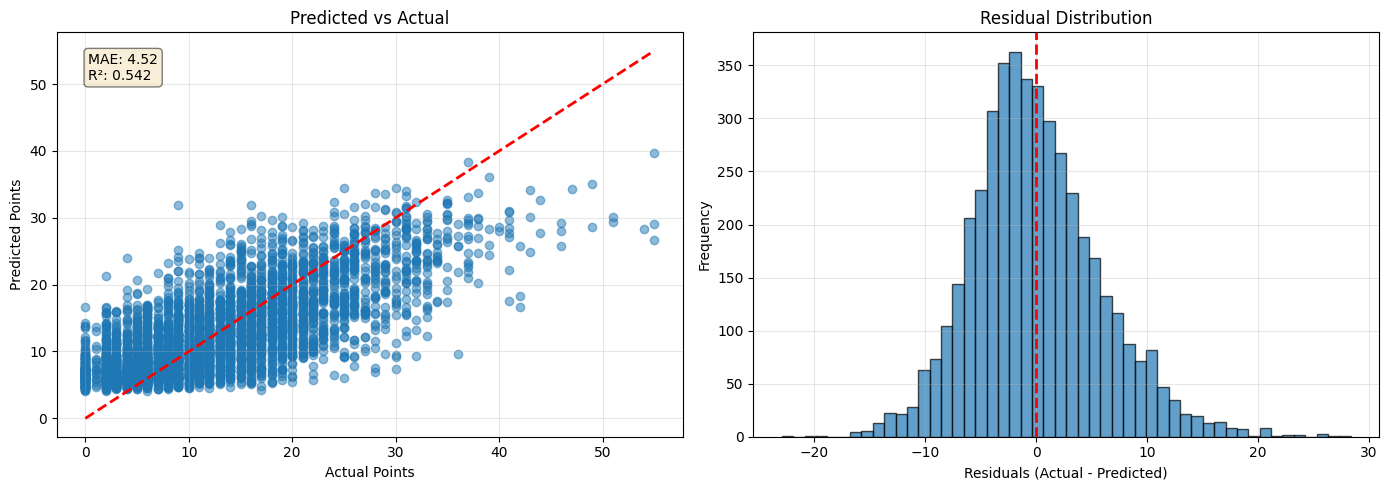

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

preds_dist = mean_model.pred_dist(val_df[features])
y_pred_mean = preds_dist.loc
y_pred_std = preds_dist.scale
y_true = val_df['PTS'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_true, y_pred_mean, alpha=0.5)
axes[0].plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

mae = mean_absolute_error(y_true, y_pred_mean)
r2 = r2_score(y_true, y_pred_mean)
axes[0].text(0.05, 0.95, f'MAE: {mae:.2f}\nR²: {r2:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

residuals = y_true - y_pred_mean
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
mean_importance_raw = mean_model.feature_importances_  
var_importance_raw = variance_model.feature_importances_    

# Average across the 2 distributions
mean_importance = mean_importance_raw.mean(axis=0)  
var_importance = var_importance_raw.mean(axis=0)    

# NOW create the DataFrame
feature_importance_df = pd.DataFrame({
    'feature': features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('mean_model', ascending=False)

# Display top features
print("\n" + "="*80)
print("TOP 50 FEATURES FOR PREDICTING POINTS (MEAN MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'mean_model']].tail(50).to_string(index=False))


TOP 50 FEATURES FOR PREDICTING POINTS (MEAN MODEL)
                            feature  mean_model
          NET_RATING_ROLLING_AVG_20    0.002658
          NET_RATING_ROLLING_AVG_10    0.002619
                  PTS_STD_5_TO_DATE    0.002606
                MEDIUM_SCORER_X_PTS    0.002579
    NET_RATING_EXPECTATION_LOCATION    0.002578
PTS_2ND_CHANCE_EXPECTATION_LOCATION    0.002547
          FGA_VOLATILITY_15_TO_DATE    0.002544
                 MIN_BOOST_STAR_OUT    0.002517
 E_OFF_RATING_VOLATILITY_20_TO_DATE    0.002498
                MEDIUM_SCORER_X_USG    0.002474
          PLUS_MINUS_ROLLING_AVG_10    0.002441
    PLUS_MINUS_EXPECTATION_LOCATION    0.002440
           FGA_EXPECTATION_LOCATION    0.002435
                   FG3A_AVG_TO_DATE    0.002434
                  FGA_STD_7_TO_DATE    0.002425
      USG_PCT_EXPECTATION_TEAM_STAR    0.002421
    PLAYER_X_MATCHUP_FORWARD_FG_PCT    0.002370
           PLUS_MINUS_ROLLING_AVG_5    0.002366
                FG3A_ROLLING_AVG_10 

In [16]:
feature_importance_df = pd.DataFrame({
    'feature': features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('var_model', ascending=False)


print("\n" + "="*80)
print("TOP 50 FEATURES FOR PREDICTING POINTS (VAR MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'var_model']].tail(50).to_string(index=False))


TOP 50 FEATURES FOR PREDICTING POINTS (VAR MODEL)
                            feature  var_model
                  FGA_STD_3_TO_DATE   0.003111
                  PTS_STD_3_TO_DATE   0.003073
              USG_PCT_ROLLING_AVG_3   0.003028
          PLUS_MINUS_ROLLING_AVG_10   0.003012
             TEAM_AST_ROLLING_AVG_3   0.003008
           NET_RATING_ROLLING_AVG_5   0.002979
           PLUS_MINUS_ROLLING_AVG_5   0.002903
                  PTS_ROLLING_AVG_3   0.002894
 E_OFF_RATING_VOLATILITY_10_TO_DATE   0.002892
                 GAMES_WITHOUT_STAR   0.002836
                   LOW_SCORER_X_FGA   0.002830
                 FTA_ROLLING_AVG_10   0.002773
                  PTS_ROLLING_AVG_5   0.002721
           PLUS_MINUS_ROLLING_AVG_3   0.002669
                 PTS_ROLLING_AVG_10   0.002652
                MEDIUM_SCORER_X_MIN   0.002559
                FG3A_ROLLING_AVG_10   0.002549
                 PTS_BOOST_STAR_OUT   0.002545
                  FGA_ROLLING_AVG_3   0.002512
         

In [14]:
validate_production_model(mean_model, variance_model, val_df, features, 'PTS', cal_factor)

=== CALIBRATION CHECK ===
Standardized residuals mean: -0.000 (should be ~0)
Standardized residuals std: 0.967 (should be ~1)
Q25: Predicted=8.5, Actual=6.0
Q50: Predicted=12.5, Actual=11.0
Q75: Predicted=16.5, Actual=18.0

MAE: 4.52
90% CI: Coverage=92.53%, Expected=90.00%
95% CI: Coverage=95.90%, Expected=95.00%
99% CI: Coverage=98.58%, Expected=99.00%


array([ 0.91160712, -1.35996399,  0.25421343, ..., -0.4899655 ,
       -0.49285544, -0.15024156], shape=(4434,))

In [42]:
import joblib

# Save NGBoost split models (mean, variance, calibration factor)
joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_PRODUCTION.pkl')
joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_PRODUCTION.pkl')
joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTION.pkl')

joblib.dump(features, 'SAVED_MODELS/feature_list.pkl')

print("="*80)
print("Models saved successfully!")
print("="*80)
print("✓ Mean model")
print("✓ Variance model")
print("✓ Calibration factor")
print("✓ Feature list")

Models saved successfully!
✓ Mean model
✓ Variance model
✓ Calibration factor
✓ Feature list


In [24]:
# import joblib

# # Save NGBoost split models (mean, variance, calibration factor)
# joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_BACKTEST.pkl')
# joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_BACKTEST.pkl')
# joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_BACKTEST.pkl')

# joblib.dump(features, 'SAVED_MODELS/feature_list.pkl')

# print("="*80)
# print("Models saved successfully!")
# print("="*80)
# print("✓ Mean model")
# print("✓ Variance model")
# print("✓ Calibration factor")
# print("✓ Feature list")

Models saved successfully!
✓ Mean model
✓ Variance model
✓ Calibration factor
✓ Feature list
